# Day 18 & 19 — ML Student Performance Prediction and Model Evaluation

## Import Libraries

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

## Load Dataset and Initial Inspection

In [79]:
df = pd.read_csv("/content/Day18_19_student_habits_performance.csv")

print("Missing values:")
display(df.isnull().sum())

print("Dataset Info:")
df.info()

numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

Missing values:


,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000

## Check Missing Values and Duplicate Records

In [42]:
print("Missing values per column:")
display(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

print("Duplicate rows:")
display(df.duplicated().sum())

print("Duplicate student_ids:")
display(df["student_id"].duplicated().sum())

Missing values per column:


,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Total missing values: 91
Duplicate rows:


np.int64(0)

Duplicate student_ids:


np.int64(0)

There are missing values in `parental_education_level`.

## Identify Numerical and Categorical Variables

In [43]:
numerical_columns = df.select_dtypes(include=np.number).columns
display(numerical_columns)
categorical_columns = df.select_dtypes(include="object").columns
display(categorical_columns)

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

## Examine Categorical Variables

In [44]:
print("Gender distribution:")
display(df["gender"].value_counts())

print("Part-time job distribution:")
display(df["part_time_job"].value_counts())

print("Diet quality distribution:")
display(df["diet_quality"].value_counts())

print("Parental education level distribution (including NaN):")
display(df["parental_education_level"].value_counts(dropna=False))

print("Internet quality distribution:")
display(df["internet_quality"].value_counts())

print("Extracurricular participation distribution:")
display(df["extracurricular_participation"].value_counts())

Gender distribution:


,count
gender,
Female,481
Male,477
Other,42


Part-time job distribution:


,count
part_time_job,
No,785
Yes,215


Diet quality distribution:


...

,count
parental_education_level,
High School,392
Bachelor,350
Master,167
NaN,91


Internet quality distribution:


,count
internet_quality,
Good,447
Average,391
Poor,162


Extracurricular participation distribution:


,count
extracurricular_participation,
No,682
Yes,318


## Distribution of Key Variables

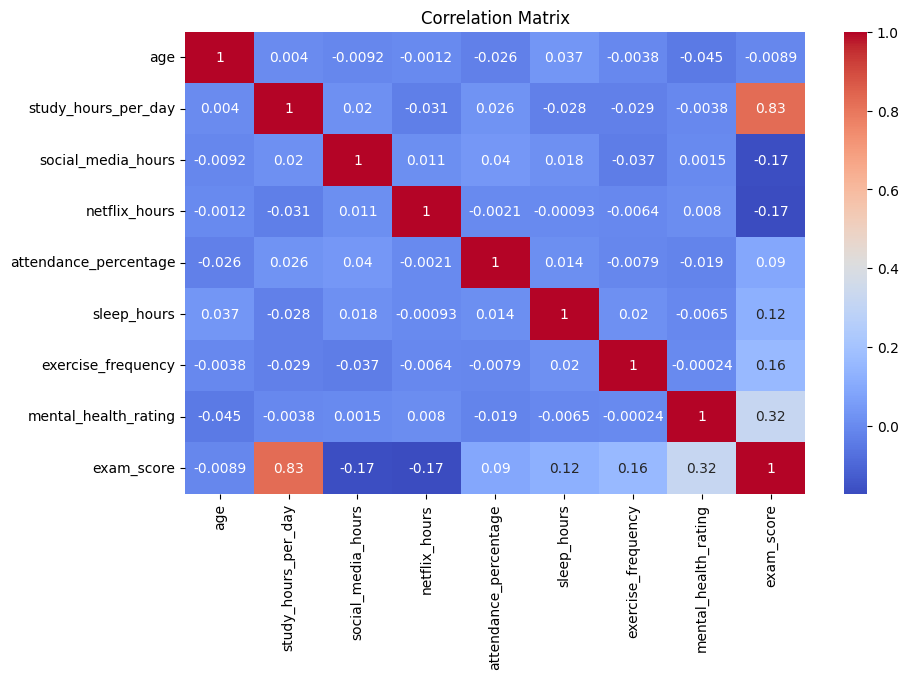

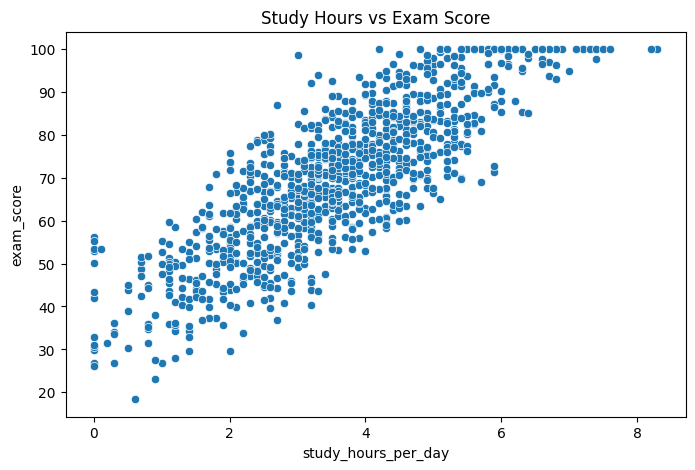

In [80]:
plt.figure(figsize=(10, 6))
correlation = df[numerical_columns].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("Study Hours vs Exam Score")
plt.show()

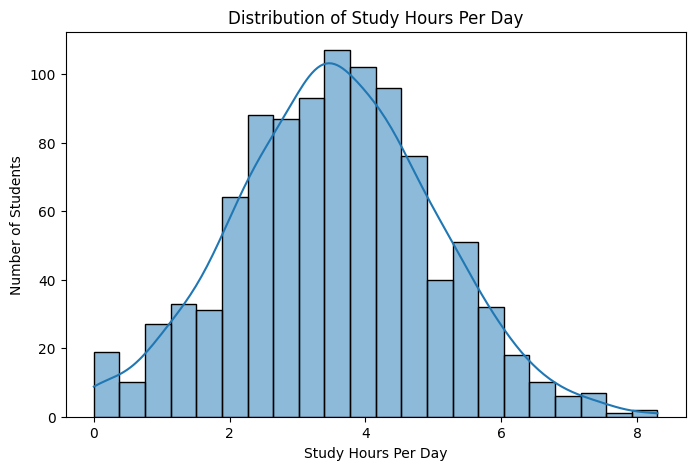

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df["study_hours_per_day"], kde=True)
plt.xlabel("Study Hours Per Day")
plt.ylabel("Number of Students")
plt.title("Distribution of Study Hours Per Day")
plt.show()

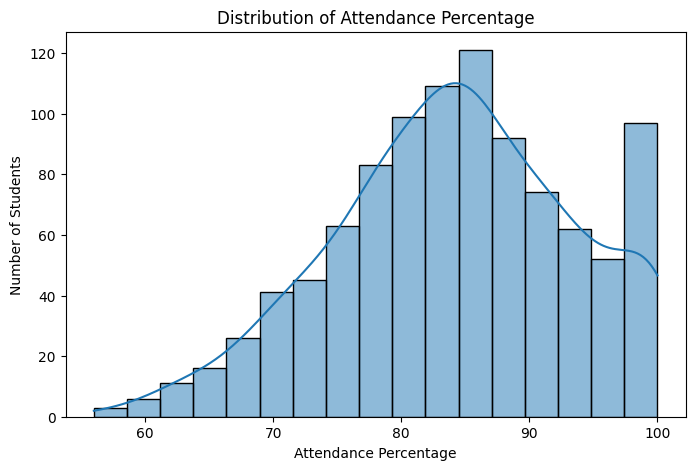

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df["attendance_percentage"], kde=True)
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Attendance Percentage")
plt.show()

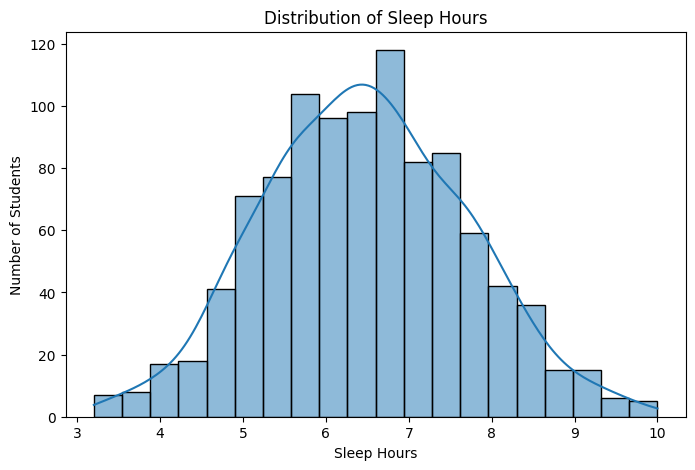

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df["sleep_hours"], kde=True)
plt.xlabel("Sleep Hours")
plt.ylabel("Number of Students")
plt.title("Distribution of Sleep Hours")
plt.show()

## Correlation Matrix

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.003971,-0.009151,-0.001174,-0.026055,0.037482,-0.003836,-0.045101,-0.008907
study_hours_per_day,0.003971,1.000000,0.020282,-0.031158,0.026264,-0.027757,-0.028701,-0.003768,0.825419
social_media_hours,-0.009151,0.020282,1.000000,0.011477,0.040479,0.018236,-0.037319,0.001496,-0.166733
netflix_hours,-0.001174,-0.031158,0.011477,1.000000,-0.002092,-0.000935,-0.006448,0.008034,-0.171779
attendance_percentage,-0.026055,0.026264,0.040479,-0.002092,1.000000,0.013756,-0.007857,-0.018745,0.089836
sleep_hours,0.037482,-0.027757,0.018236,-0.000935,0.013756,1.000000,0.019769,-0.006508,0.121683
exercise_frequency,-0.003836,-0.028701,-0.037319,-0.006448,-0.007857,0.019769,1.000000,-0.000242,0.160107
mental_health_rating,-0.045101,-0.003768,0.001496,0.008034,-0.018745,-0.006508,-0.000242,1.000000,0.321523
exam_score,-0.008907,0.825419,-0.166733,-0.171779,0.089836,0.121683,0.160107,0.321523,1.000000


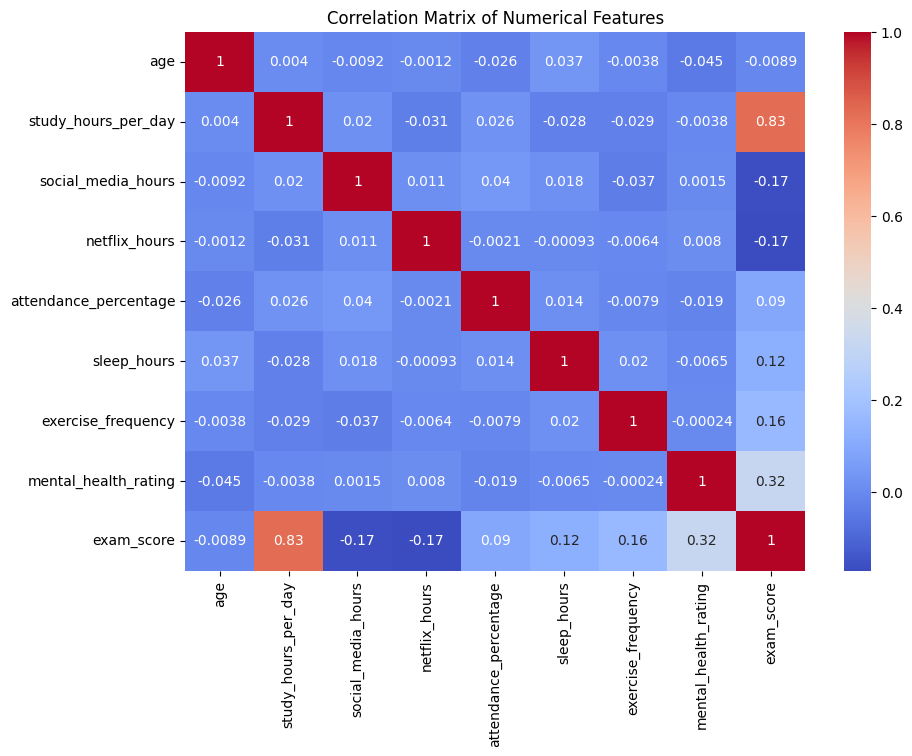

In [49]:
correlation = df[numerical_columns].corr()
display(correlation)

plt.figure(figsize=(10,7))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Correlation With Exam Score

In [50]:
exam_correlation = df[numerical_columns].corr()["exam_score"].sort_values(ascending=False)
display(exam_correlation)

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


The strongest relationship in this dataset is between **study hours and exam score**.

## Relationships with Exam Score (Numerical Features)

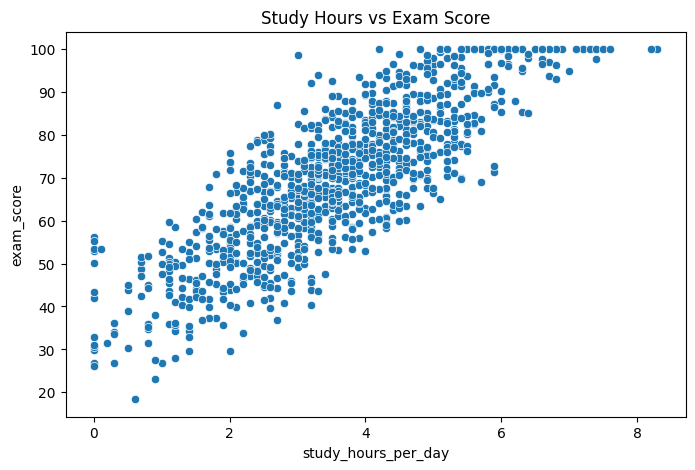

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="exam_score"
)
plt.title("Study Hours vs Exam Score")
plt.show()

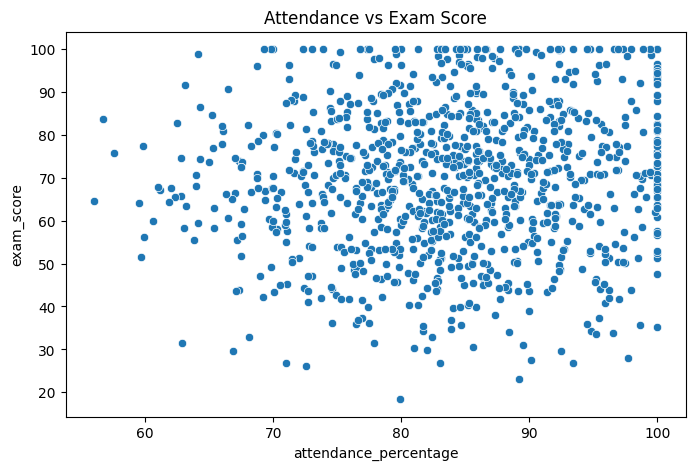

In [52]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="exam_score"
)
plt.title("Attendance vs Exam Score")
plt.show()

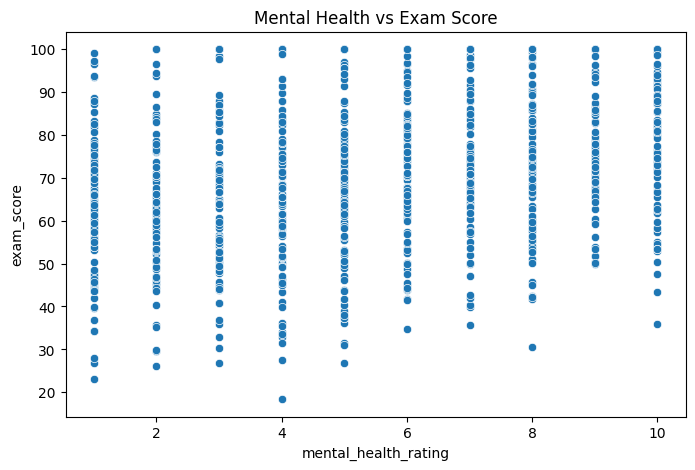

In [53]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="mental_health_rating",
    y="exam_score"
)
plt.title("Mental Health vs Exam Score")
plt.show()

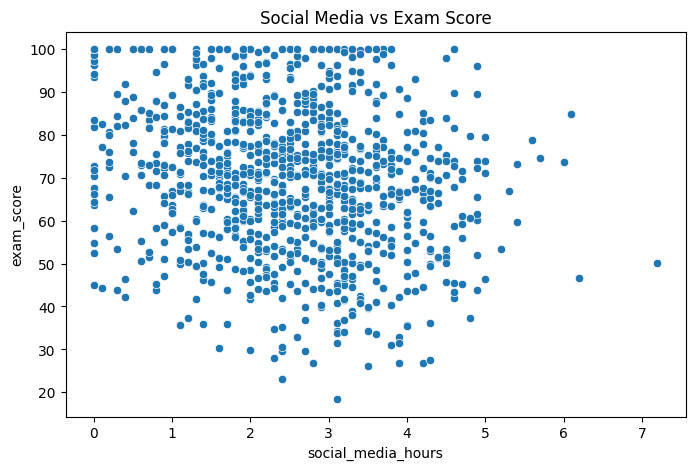

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="social_media_hours",
    y="exam_score"
)
plt.title("Social Media vs Exam Score")
plt.show()

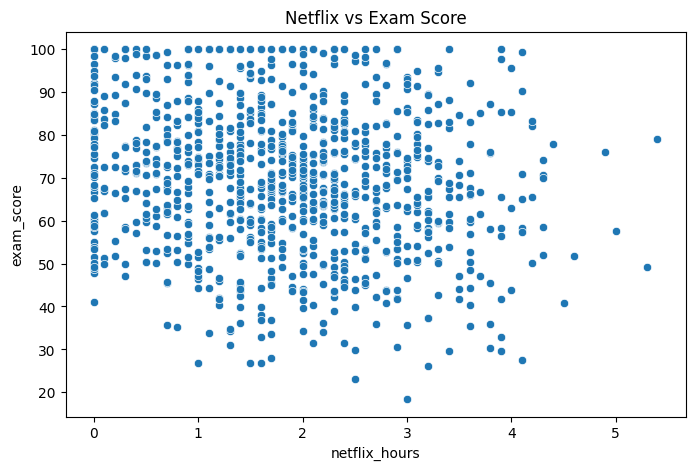

In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="netflix_hours",
    y="exam_score"
)
plt.title("Netflix vs Exam Score")
plt.show()

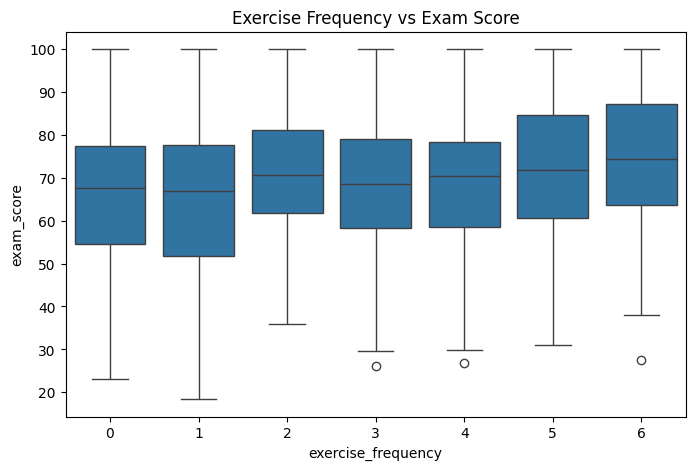

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="exercise_frequency",
    y="exam_score"
)
plt.title("Exercise Frequency vs Exam Score")
plt.show()

## Relationships with Exam Score (Categorical Variables)

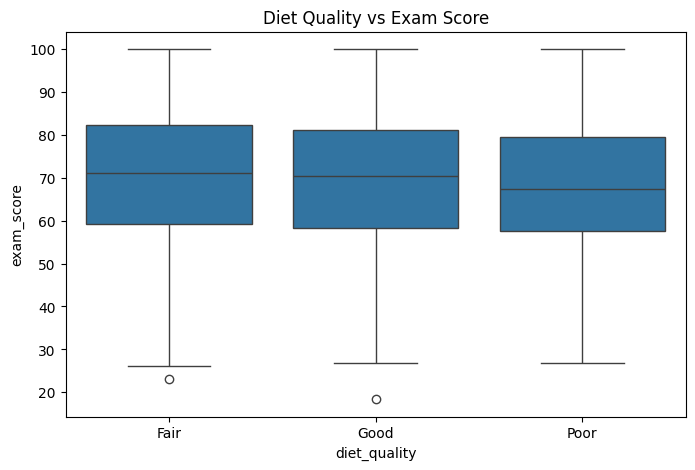

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="diet_quality",
    y="exam_score"
)
plt.title("Diet Quality vs Exam Score")
plt.show()

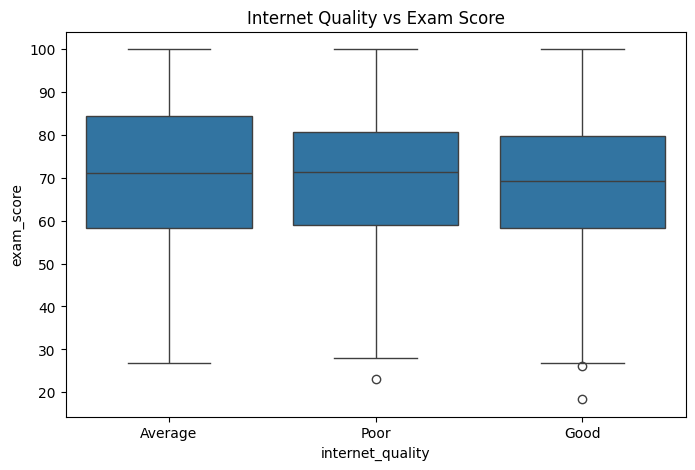

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="internet_quality",
    y="exam_score"
)
plt.title("Internet Quality vs Exam Score")
plt.show()

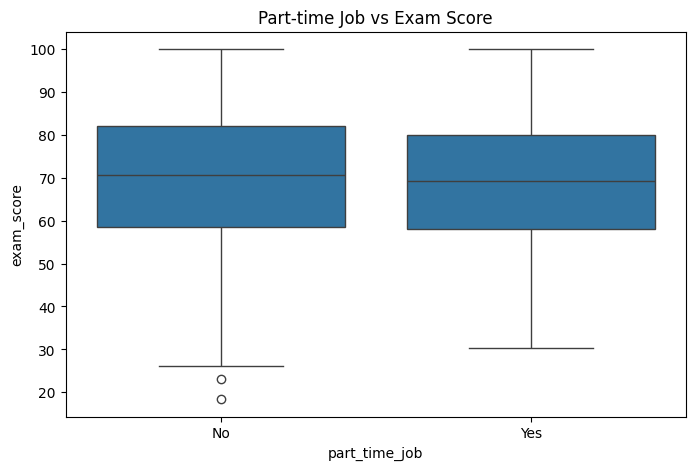

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="part_time_job",
    y="exam_score"
)
plt.title("Part-time Job vs Exam Score")
plt.show()

## Check Potential Outliers

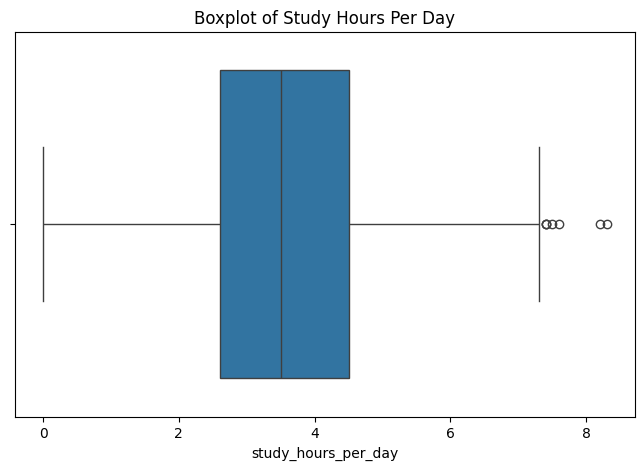

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["study_hours_per_day"])
plt.title("Boxplot of Study Hours Per Day")
plt.show()

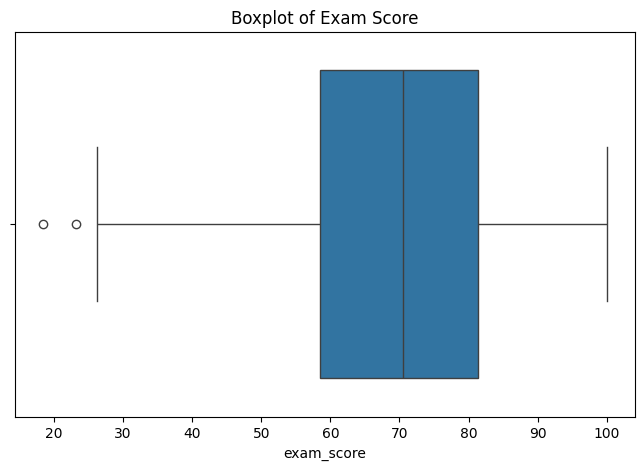

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["exam_score"])
plt.title("Boxplot of Exam Score")
plt.show()

In [62]:
Q1 = df["study_hours_per_day"].quantile(0.25)
Q3 = df["study_hours_per_day"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Lower limit for study_hours_per_day: {lower_limit}")
print(f"Upper limit for study_hours_per_day: {upper_limit}")

outliers = df[
    (df["study_hours_per_day"] < lower_limit) |
    (df["study_hours_per_day"] > upper_limit)
]

print(f"Number of outliers in study_hours_per_day: {outliers.shape[0]}")

Lower limit for study_hours_per_day: -0.24999999999999956
Upper limit for study_hours_per_day: 7.35
Number of outliers in study_hours_per_day: 7


## Prepare Data

We can remove `student_id` because it is only an identifier.

In [63]:
X = df.drop(columns=["student_id", "exam_score"])
y = df["exam_score"]

print("X head:")
display(X.head())
print("y head:")
display(y.head())

X head:


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No


y head:


,exam_score
0,56.2
1,100.0
2,34.3
3,26.8
4,66.4


## Train-Test Split

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800, 14)
X_test shape: (200, 14)


## Separate Numerical and Categorical Features

In [65]:
numerical_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include="object").columns

print("Numerical features:")
display(numerical_features)
print("Categorical features:")
display(categorical_features)

Numerical features:


Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')

Categorical features:


Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object')

## Preprocessing Pipelines

In [81]:
X = df.drop(columns=["student_id", "exam_score"])
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

This ensures that preprocessing is fitted using the **training data only**, preventing data leakage.

# Linear Regression

## Create and Train Model

In [82]:
lin_reg = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MAE: 4.19
RMSE: 5.15
R2 Score: 0.90


## Generate Predictions

In [68]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

print("First 10 test predictions:")
display(y_test_pred[:10])

First 10 test predictions:


array([66.20077804, 75.12000136, 78.05849507, 73.33465453, 61.01915606,
       54.05845019, 75.57324219, 55.04257761, 40.67372532, 72.41772902])

## Regression Evaluation

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training MAE: {train_mae:.2f}")
print(f"Testing MAE: {test_mae:.2f}")

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Training MSE: {train_mse:.2f}")
print(f"Testing MSE: {test_mse:.2f}")

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R2: {train_r2:.2f}")
print(f"Testing R2: {test_r2:.2f}")

Training MAE: 4.21
Testing MAE: 4.19
Training MSE: 28.57
Testing MSE: 26.53
Training RMSE: 5.34
Testing RMSE: 5.15
Training R2: 0.90
Testing R2: 0.90


## Actual vs Predicted Scores (Linear Regression)

,Actual,Predicted
0,64.2,66.200778
1,72.7,75.120001
2,79.0,78.058495
3,79.5,73.334655
4,58.2,61.019156
5,53.4,54.058450
6,70.8,75.573242
7,62.5,55.042578
8,36.8,40.673725
9,67.6,72.417729


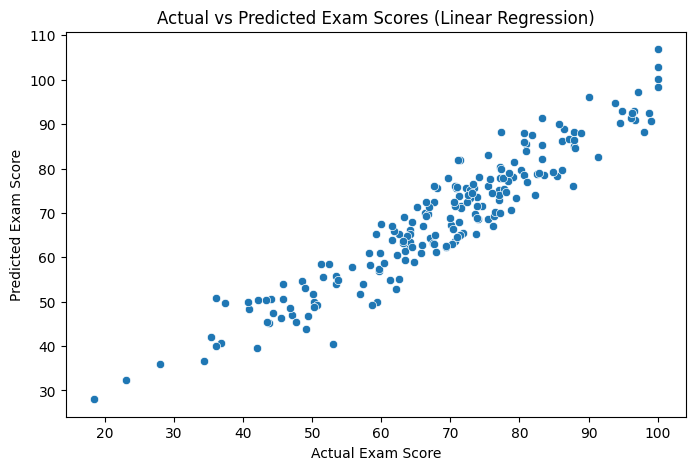

In [70]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

display(comparison.head(10))

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=y_test,
    y=y_test_pred
)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores (Linear Regression)")
plt.show()

# Classification Problem

Now we convert exam_score into **Pass/Fail**.
A student with a score of **50 or above is considered Pass**.

## Create Pass/Fail Target and Prepare Classification Data

In [83]:
df["result"] = np.where(df["exam_score"] >= 50, "Pass", "Fail")

X_c = df.drop(columns=["student_id", "exam_score", "result"])
y_c = df["result"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

log_reg = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000))])
log_reg.fit(X_train_c, y_train_c)

y_pred_c = log_reg.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 0.955

Classification Report:
               precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



## Classification Preprocessing

In [72]:
classification_numerical = X_train_class.select_dtypes(include=np.number).columns
classification_categorical = X_train_class.select_dtypes(include="object").columns

classification_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        classification_numerical
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        classification_categorical
    )
])

## Logistic Regression

## Create and Train Classification Model

In [73]:
from sklearn.linear_model import LogisticRegression

classification_model = Pipeline([
    ("preprocessor", classification_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

classification_model.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

## Generate Classification Predictions

In [74]:
y_train_class_pred = classification_model.predict(X_train_class)
y_test_class_pred = classification_model.predict(X_test_class)

print("First 10 test classification predictions:")
display(y_test_class_pred[:10])

First 10 test classification predictions:


array(['Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass',
       'Pass', 'Pass'], dtype=object)

## Classification Evaluation Metrics

Training Accuracy: 0.96
Testing Accuracy: 0.95
Confusion Matrix:


array([[ 21,   5],
       [  4, 170]])

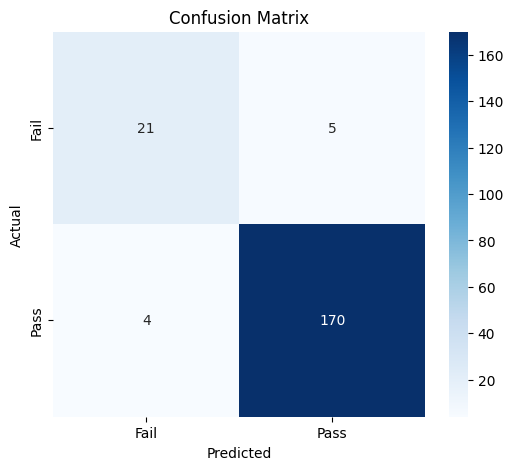

Precision: 0.97
Recall: 0.98
F1 Score: 0.97
Classification Report:
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

train_accuracy = accuracy_score(
    y_train_class,
    y_train_class_pred
)

test_accuracy = accuracy_score(
    y_test_class,
    y_test_class_pred
)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

cm = confusion_matrix(
    y_test_class,
    y_test_class_pred
)

print("Confusion Matrix:")
display(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

precision = precision_score(
    y_test_class,
    y_test_class_pred,
    pos_label="Pass"
)

print(f"Precision: {precision:.2f}")

recall = recall_score(
    y_test_class,
    y_test_class_pred,
    pos_label="Pass"
)

print(f"Recall: {recall:.2f}")

f1 = f1_score(
    y_test_class,
    y_test_class_pred,
    pos_label="Pass"
)

print(f"F1 Score: {f1:.2f}")

print("Classification Report:")
print(
    classification_report(
        y_test_class,
        y_test_class_pred
    )
)

## Training vs Testing Performance Comparison

In [76]:
print("Linear Regression Performance")
print(f"Training R2: {train_r2:.2f}")
print(f"Testing R2: {test_r2:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")

print("\nLogistic Regression Performance")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Linear Regression Performance
Training R2: 0.90
Testing R2: 0.90
Training RMSE: 5.34
Testing RMSE: 5.15

Logistic Regression Performance
Training Accuracy: 0.96
Testing Accuracy: 0.95


## Classification Prediction Comparison

In [77]:
classification_comparison = pd.DataFrame({
    "Actual": y_test_class.values,
    "Predicted": y_test_class_pred
})

display(classification_comparison.head(10))

,Actual,Predicted
0,Pass,Pass
1,Pass,Fail
2,Pass,Pass
3,Pass,Pass
4,Pass,Pass
5,Pass,Pass
6,Pass,Pass
7,Pass,Pass
8,Pass,Pass
9,Pass,Pass
